[OK] Raíz fijada en: 'Q9I968.1AcProt.mucrosquamatus'


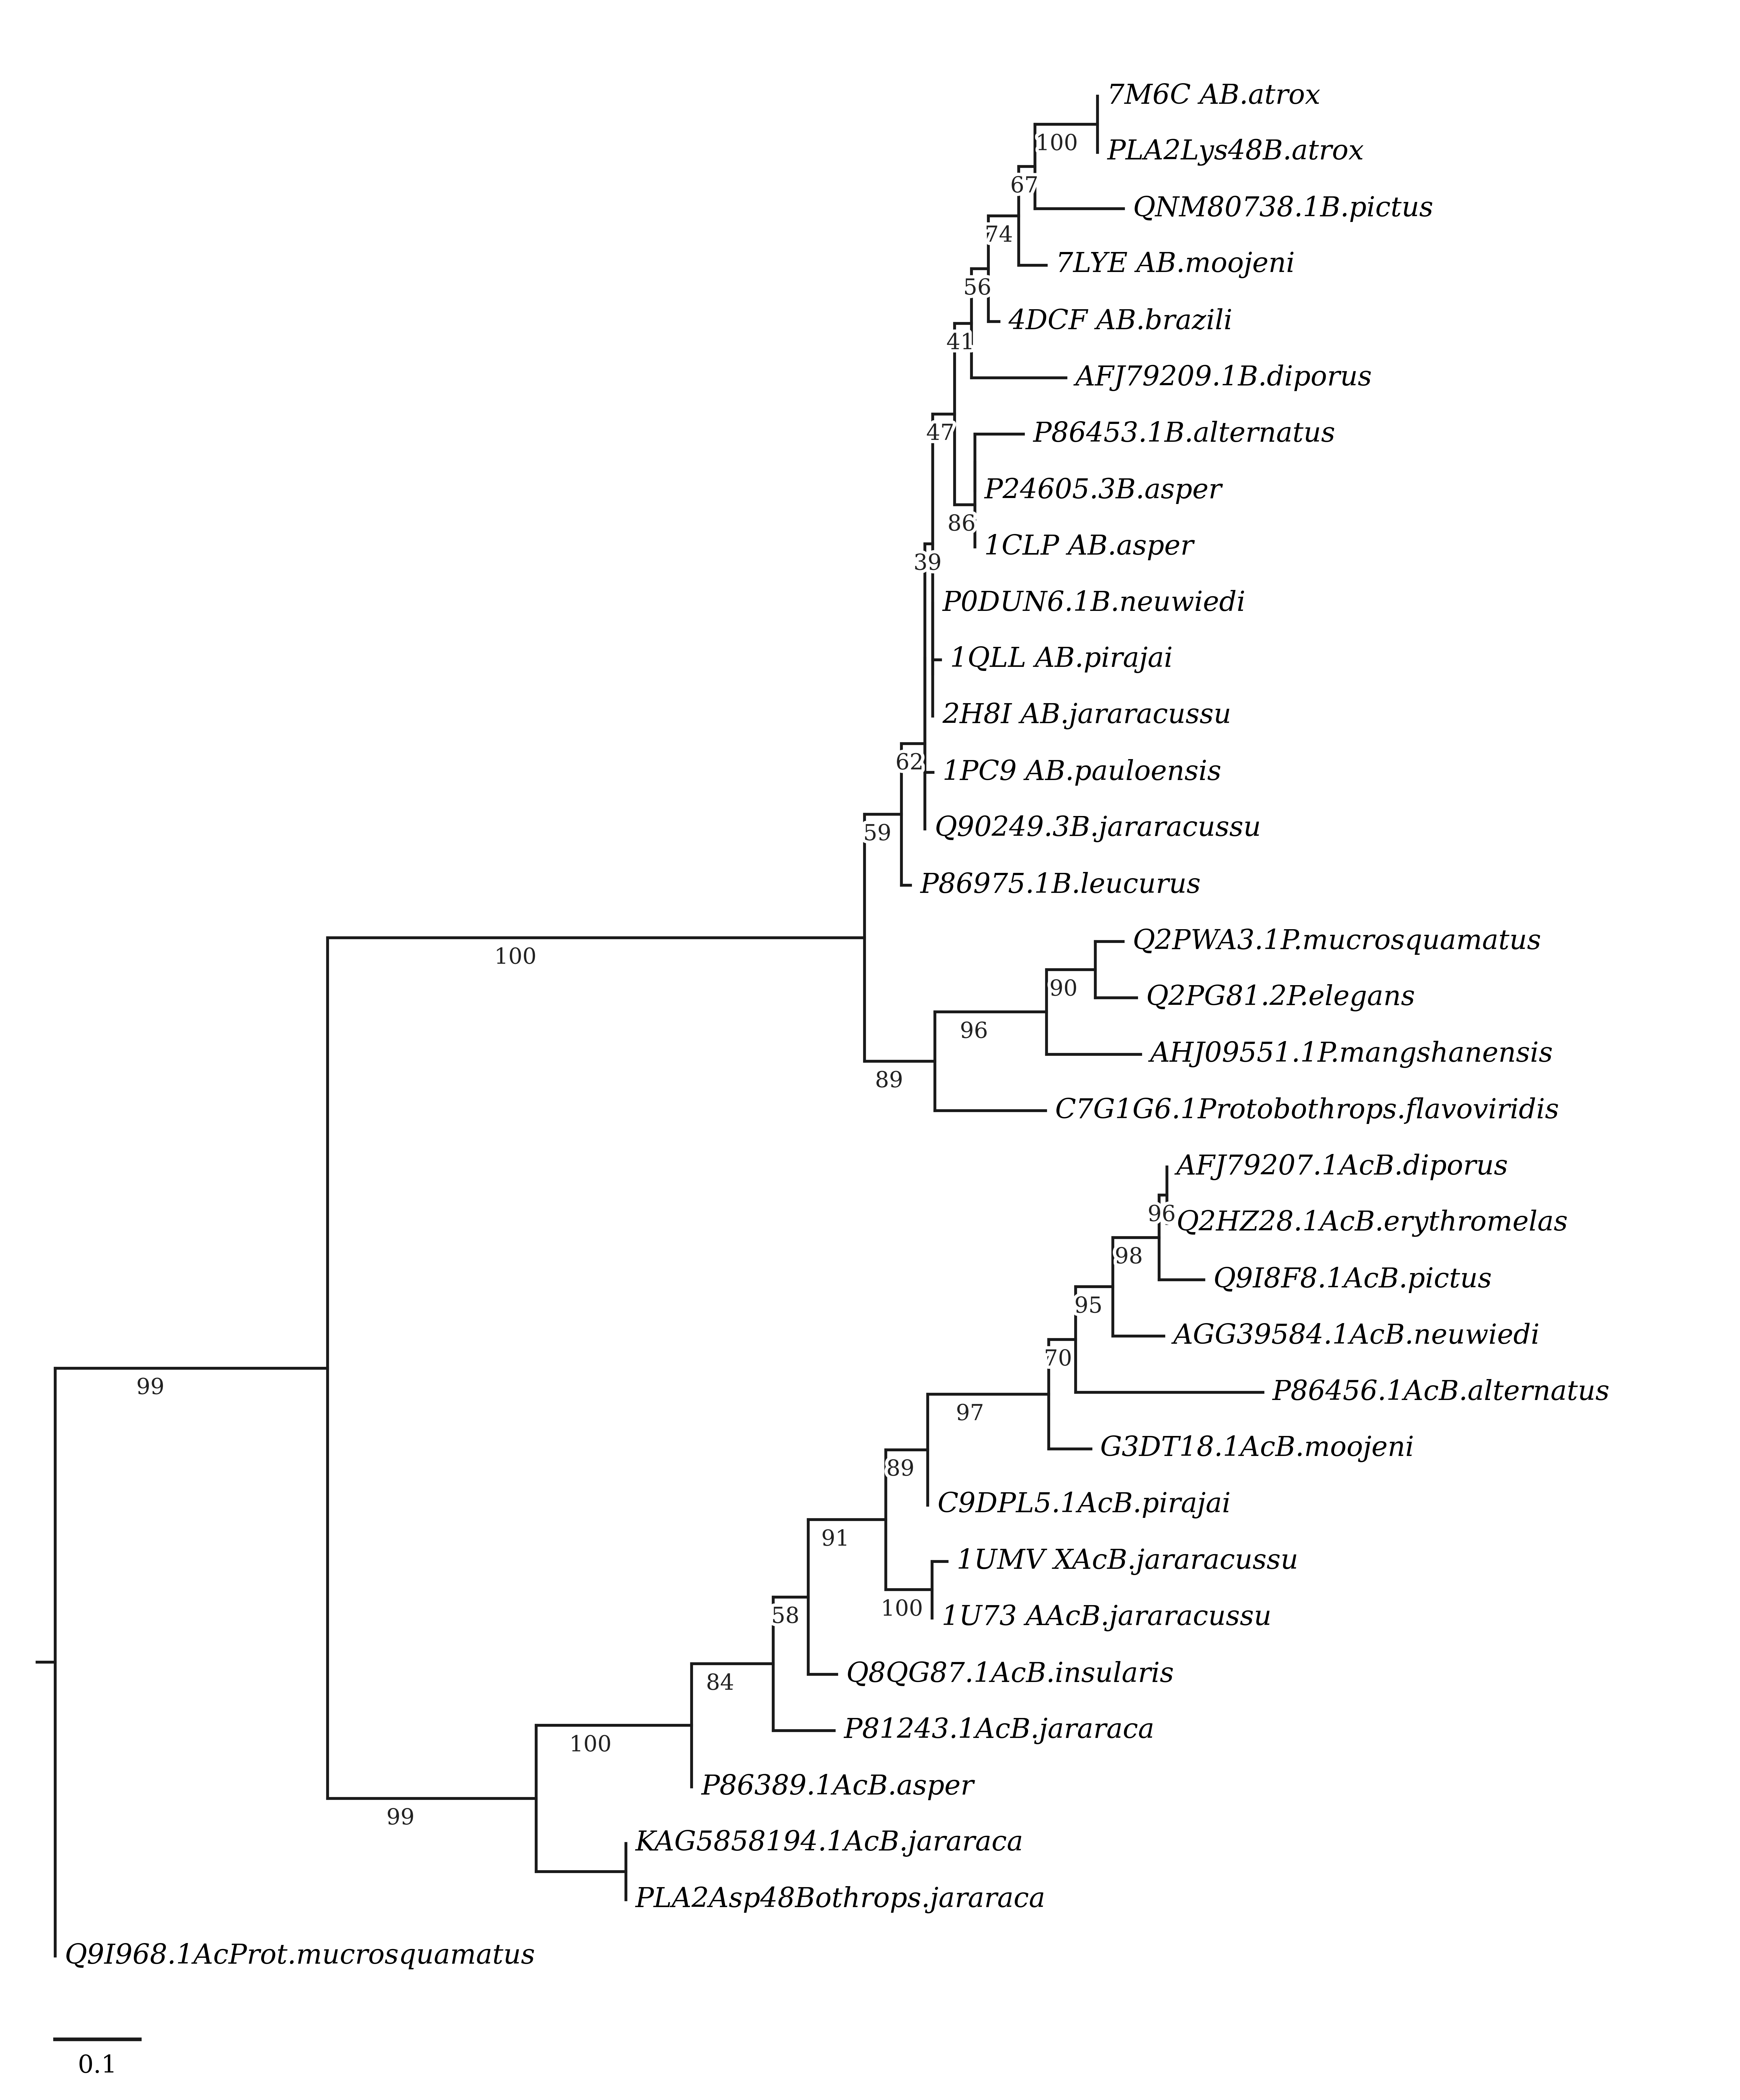


[LISTO] Archivo exportado sin superposiciones: 'Arbol_Filogenetico_Perfecto.png'.


In [ ]:
# ==============================================================================
# PIPELINE FILOGENÉTICO - CALIDAD PUBLICACIÓN ( ANTI-SUPERPOSICIÓN FINAL )
# ==============================================================================
!pip install biopython matplotlib -q

import io
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
from Bio import Phylo

# ==============================================================================
# 1. PARÁMETROS CONFIGURABLES
# ==============================================================================
ARCHIVO_INPUT = "PLA2_WAG100k.treefile"
ESPECIE_RAIZ = "Q9I968.1 AcProt.mucrosquamatus"

# Omitir Bootstrap en ramas menores a este valor (evita amontonamiento extremo)
UMBRAL_MINIMO_RAMA = 0.005

DPI_CALIDAD = 600
NOMBRE_SALIDA = "Arbol_Filogenetico_Perfecto.png"
VALOR_BARRA_ESCALA = 0.1

# ==============================================================================
# 2. FUNCIONES DE PROCESAMIENTO Y MOTOR CARTESIANO
# ==============================================================================

def procesar_arbol(ruta, nombre_raiz):
    """Carga y enraíza el árbol buscando coincidencias flexibles."""
    arbol = Phylo.read(ruta, "newick")
    raiz_busqueda = nombre_raiz.replace(" ", "").lower()

    obj_raiz = None
    for terminal in arbol.get_terminals():
        if raiz_busqueda in terminal.name.replace(" ", "").lower() or "q9i968.1" in terminal.name.lower():
            obj_raiz = terminal
            break

    if obj_raiz:
        arbol.root_with_outgroup(obj_raiz)
        print(f"[OK] Raíz fijada en: '{obj_raiz.name}'")

    arbol.ladderize()
    return arbol


def calcular_coordenadas_estiradas(arbol):
    """Calcula X (distancia evolutiva) e Y estirando el espacio vertical para dar aire al texto."""
    pos_x = arbol.depths()
    terminales = arbol.get_terminals()

    # FACTOR DE ESTIRAMIENTO VERTICAL: 1.35 en lugar de 1.0 para separar las ramas densas
    pos_y = {term: float(idx * 1.35) for idx, term in enumerate(terminales)}

    for clado in arbol.find_clades(order='postorder'):
        if not clado.is_terminal():
            hijos_y = [pos_y[h] for h in clado.clades if h in pos_y]
            pos_y[clado] = (min(hijos_y) + max(hijos_y)) / 2.0 if hijos_y else 0.0

    return pos_x, pos_y


def renderizar_arbol_perfecto(arbol, pos_x, pos_y):
    """Renderiza el árbol con escudo de legibilidad en los textos y espaciado optimizado."""
    num_hojas = len(arbol.get_terminals())
    alto_canvas = max(8, num_hojas * 0.42)  # Aumentamos ligeramente el lienzo vertical
    ancho_canvas = max(10, alto_canvas * 0.82)

    fig, ax = plt.subplots(figsize=(ancho_canvas, alto_canvas), dpi=DPI_CALIDAD)
    max_x = max(pos_x.values())

    # A. DIBUJAR ESQUELETO (Líneas sólidas clásicas)
    for clado in arbol.find_clades():
        if clado in pos_x and clado in pos_y:
            x_p = pos_x[clado]
            if clado.clades:
                ys = [pos_y[h] for h in clado.clades if h in pos_y]
                if ys:
                    ax.plot([x_p, x_p], [min(ys), max(ys)], color='#1A1A1A', lw=1.1, zorder=1)
            for h in clado.clades:
                if h in pos_x and h in pos_y:
                    ax.plot([x_p, pos_x[h]], [pos_y[h], pos_y[h]], color='#1A1A1A', lw=1.1, zorder=1)

    raiz = arbol.root
    ax.plot([pos_x[raiz] - (max_x * 0.015), pos_x[raiz]], [pos_y[raiz], pos_y[raiz]], color='#1A1A1A', lw=1.1)

    # B. NOMBRES DE LAS ESPECIES (Terminales)
    for clado in arbol.get_terminals():
        ax.text(
            pos_x[clado] + (max_x * 0.008), pos_y[clado],
            clado.name.replace("_", " "),
            va='center', ha='left',
            fontsize=10.5, fontfamily='serif', fontstyle='italic', color='#000000'
        )

    # C. VALORES DE BOOTSTRAP (Internos) - REUBICADOS CON ESCUDO BLANCO
    halo_blanco = [PathEffects.withStroke(linewidth=2.5, foreground="white")]

    for clado in arbol.find_clades():
        if not clado.is_terminal() and clado != arbol.root:
            longitud = clado.branch_length if clado.branch_length else 0.0

            if longitud < UMBRAL_MINIMO_RAMA:
                continue

            soporte = None
            if clado.confidence is not None:
                soporte = int(clado.confidence) if float(clado.confidence).is_integer() else clado.confidence
            elif clado.name:
                soporte = clado.name

            if soporte is not None:
                padres = [p for p in arbol.find_clades() if clado in p.clades]
                x_padre = pos_x[padres[0]] if padres else pos_x[clado] - longitud

                # CÁLCULO DE REUBICACIÓN:
                # X = Al 35% del camino de la rama horizontal (lo aleja de la línea vertical)
                x_optimo = x_padre + (longitud * 0.35)
                # Y = Desplazado sutilmente hacia ABAJO (-0.22) para liberar el techo de la rama
                y_optimo = pos_y[clado] - 0.22

                texto = ax.text(
                    x_optimo, y_optimo,
                    str(soporte),
                    va='top', ha='center',
                    fontsize=8.5, fontfamily='serif', color='#222222', zorder=3
                )
                # Aplicar escudo delineado blanco para evitar que las ramas lo tachen
                texto.set_path_effects(halo_blanco)

    # D. ESCALA MINIMALISTA EN ESQUINA INFERIOR
    ax.axis('off')
    x_esc, y_esc = 0, -2.0

    ax.plot([x_esc, x_esc + VALOR_BARRA_ESCALA], [y_esc, y_esc], color='#1A1A1A', lw=1.4)
    ax.text(x_esc + (VALOR_BARRA_ESCALA / 2), y_esc - 0.35, f"{VALOR_BARRA_ESCALA}",
            va='top', ha='center', fontsize=9.5, fontfamily='serif')

    ax.set_xlim(- (max_x * 0.03), max_x * 1.38)
    ax.set_ylim(y_esc - 1.0, (num_hojas * 1.35) + 0.5)

    plt.savefig(NOMBRE_SALIDA, dpi=DPI_CALIDAD, bbox_inches='tight')
    plt.show()
    print(f"\n[LISTO] Archivo exportado sin superposiciones: '{NOMBRE_SALIDA}'.")

# ==============================================================================
# 3. EJECUCIÓN
# ==============================================================================
mi_arbol = procesar_arbol(ARCHIVO_INPUT, ESPECIE_RAIZ)
px, py = calcular_coordenadas_estiradas(mi_arbol)
renderizar_arbol_perfecto(mi_arbol, px, py)